### Code funzionante

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [2]:
bits = 16

In [3]:

LUT_BITS = 8
LUT_SIZE = 1 << LUT_BITS

lut = [
    (1 << (bits * 2)) //
    ((1 << (bits - 1)) + (i << (bits - 1 - LUT_BITS)))
    for i in range(LUT_SIZE)
]

In [14]:
a = random.getrandbits(bits)
b = random.getrandbits(bits)



s = bits - b.bit_length()

b_norm = b << s

idx = (b_norm >> (bits - 1 - LUT_BITS)) 

idx = idx & (LUT_SIZE - 1)

x = lut[idx]

print("x  :", a*x >> (bits + b.bit_length()))
print("a/b:", a//b)

print("Precision bits of LUT", bits - ((a*x >> (bits + b.bit_length())) - a//b).bit_length())

for _ in range(0):
    print(x)
    x = (x * ((1 << (bits * 2 + 1)) - b_norm * x)) >> (bits * 2)

print("last", x)
result = (a * x)
print("final", result)
result = result >> bits
print("final shifted", result)
result = result << bits - b.bit_length() # Blind rotation
print("final shifted", result)
result = result >> bits
print("final shifted", result)

print("***")
print("A:", a)
print("B:", b)
print("My res:", result)
print("Expect:", a // b)

x  : 301
a/b: 301
Precision bits of LUT 16
last 74898
final 1262555586
final shifted 19265
final shifted 19727360
final shifted 301
***
A: 16857
B: 56
My res: 301
Expect: 301


In [26]:
lut[17]

122910

In [91]:
bin(b.bit_length())

'0b1101'

In [92]:
bits - 1 - LUT_BITS

7

In [93]:
bits

16

In [94]:
s

3

In [95]:
b_norm

64064

### Todo: map the LUT as a polynomial

In [96]:
def get_bit(n, i):
    return (n >> i) & 1

In [97]:
def polylut(bit = 0):
    N = LUT_SIZE
    seq = np.array([get_bit(lut[i], bit) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

In [98]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [99]:
polyluts = []

for bit in range(bits + 2):
    f = polylut(bit)
    
    c = Chebyshev(0, LUT_SIZE, 851, f)
    
    polyluts.append(c)

1.8121832121714698e-08

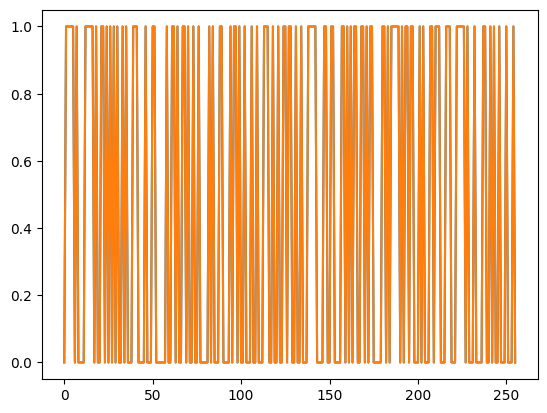

In [100]:
f = polylut(0)

c = Chebyshev(0, LUT_SIZE, 851, f)

x = np.arange(0, LUT_SIZE, 1)

y = np.vectorize(c.eval)(x)
plt.plot(x, y)

y_real = np.vectorize(f)(x)
plt.plot(x, y_real)


max(abs(y - y_real))

---

### Making the LUT polynomial

In [101]:
s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> (bits - 1 - LUT_BITS)) & (LUT_SIZE - 1)

idx

244

In [102]:
binx = []

for i in range(bits * 2):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))

In [106]:
polyluts[0].c

[0.8707774007107852,
 -0.031497665530690444,
 -0.01671224740892818,
 -0.06056170592527011,
 -0.026038679519684232,
 0.009847528989683673,
 -0.026768422026040704,
 0.022353343443898336,
 -0.023898593468778664,
 0.015881734685371775,
 -0.02842462001941671,
 0.01431825856820546,
 -0.03127698713523122,
 0.021646998286656442,
 -0.057663628718232364,
 0.041540869093829765,
 -0.04899964524965308,
 0.048621560551769784,
 -0.05077094320186359,
 0.028371410778063117,
 -0.07280302935926768,
 0.01475881143118586,
 -0.04749525522944588,
 0.005375775252717615,
 0.007998744215063552,
 0.002364121177954931,
 -0.012110193969332635,
 0.0030498607829353023,
 -0.0017889879476067647,
 0.0017144852009445494,
 -0.0007907920415699241,
 0.0015473736506662523,
 -0.05572960203466276,
 0.021550976963644133,
 -0.006200884653924637,
 0.050249793162001045,
 0.004942858164415753,
 0.01106295778665447,
 0.003173531656171315,
 -0.010727278883071322,
 0.014951314853220926,
 -0.021541368055051788,
 0.021102978699828478,


In [103]:
polydec = ([round(x) for x in list(binx)][::-1])

In [104]:
n = int("".join(map(str, polydec)), 2)

# We check that the polynomial LUT and the actual LUT are equal
n == lut[idx]

True

In [105]:
x = n

for _ in range(4):
    term = b_norm * x                  # Mult
    term = 2 ** (bits * 2 + 1) - term  # Implementato come !term + 1, dove i bit più alti di 33 sono a 0
    
    x = x * term                       # Mult normale
    x = x >> bits * 2                  # Shift gratis

result = (a * x) >> (bits * 2 - s)

print(result)
print(a // b)

3
3


In [ ]:
##
## Expected: 3.5 minutes to evaluate (optimization might be smaller bootstrap tables)
##